# SITCOM on LDCT

This notebook provides a practical **LDCT image-domain denoising demo** using the SITCOM algorithm.

Reference: *Step-wise Triple-Consistent Diffusion Sampling for Inverse Problems* (Algorithm 1).

**Important notes:**
- The official SITCOM paper reports medical results on **MRI**, not LDCT; this is a feasibility adaptation.
- For meaningful results, supply a CT-domain pretrained diffusion checkpoint.
- The FFHQ checkpoint (`ffhq_10m.pt`) can be used for quick pipeline testing only.
- Run this notebook from inside the cloned SITCOM repository root.

## 1. Environment Setup

In [26]:
import os
import sys
import time
from pathlib import Path

import numpy as np
import torch
import yaml
from PIL import Image
import matplotlib.pyplot as plt

try:
    from skimage.metrics import peak_signal_noise_ratio, structural_similarity
except Exception:
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "scikit-image", "-q"])
    from skimage.metrics import peak_signal_noise_ratio, structural_similarity

try:
    from diffusers import DDIMScheduler  # Official SITCOM dependency
except Exception:
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "diffusers", "-q"])
    from diffusers import DDIMScheduler

# Locate SITCOM repository root
repo_root = Path.cwd()
if not (repo_root / "guided_diffusion").exists():
    if (repo_root / "SITCOM" / "guided_diffusion").exists():
        repo_root = repo_root / "SITCOM"
    else:
        raise RuntimeError(
            "Cannot find SITCOM root. "
            "Run this notebook inside SITCOM/ or the workspace root."
        )

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from guided_diffusion.unet import create_model

torch.manual_seed(123)
np.random.seed(123)
# print(f"repo_root = {repo_root}")

## 2. Configuration

Key hyperparameters correspond to **Algorithm 1** in the SITCOM paper:
- `N_STEP` → N  (number of outer diffusion sampling steps)
- `K_INNER` → K  (number of inner gradient update steps per diffusion step)
- `LAMBDA`  → λ  (regularization weight for the C3 Closeness term)
- `LEARNING_RATE` → γ (Adam step size)
- `DELTA`   → δ  (stopping criterion threshold)

In [ ]:
# ==================== User Config ====================
# NDCT_DIR = Path("/egr/research-slim/hy2786/SITCOM/data/ldct_demo/ndct")# clean/full-dose CT PNG slices
# LDCT_DIR = Path("/egr/research-slim/hy2786/SITCOM/data/ldct_demo/ldct")# paired low-dose CT(optional, not necessary)
NDCT_DIR = Path("change to your own clean/full-dose CT PNG slices")# clean/full-dose CT PNG slices
LDCT_DIR = Path("change to your own paired low-dose CT")# paired low-dose CT(optional, not necessary)


MAX_IMAGES   = 4
IMAGE_SIZE   = 256
OUTPUT_DIR   = repo_root / "results" / "ldct_demo"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

MODEL_CONFIG_PATH = repo_root / "configs" / "model_config.yaml"
CKPT_PATH         = repo_root / "models" / "ffhq_10m.pt"
DEVICE            = "cuda" if torch.cuda.is_available() else "cpu"

# ------- SITCOM Algorithm 1 hyperparameters -------
N_STEP        = 20       # N: outer diffusion steps
K_INNER       = 300      # K: inner gradient update steps
LEARNING_RATE = 0.02    # γ: Adam learning rate
LAMBDA        = 0.1     # λ: regularization for C3 Closeness term (‖x_i - v_i‖²)
DELTA         = 0.05    # δ: stopping criterion threshold (noise level estimate)
# ---------------------------------------------------

USE_EXISTING_LDCT = LDCT_DIR.exists() and len(list(LDCT_DIR.glob("*.png"))) > 0

#--------------------------------show info, you can uncomment it if you want to see the info--------------------------------
# print(f"DEVICE={DEVICE}")
# print(f"NDCT_DIR={NDCT_DIR}")
# print(f"LDCT_DIR={LDCT_DIR}  (use_existing={USE_EXISTING_LDCT})")
# print(f"OUTPUT_DIR={OUTPUT_DIR}")
# print(f"\nSITCOM hyperparams: N={N_STEP}, K={K_INNER}, γ={LEARNING_RATE}, λ={LAMBDA}, δ={DELTA}")

if not CKPT_PATH.exists():
    raise FileNotFoundError(
        f"Checkpoint not found: {CKPT_PATH}\n"
        "Download ffhq_10m.pt from the SITCOM README and place it under SITCOM/models/."
    )

## 3. Data Loading & LDCT Simulation

In [28]:
def list_pngs(folder: Path):
    return sorted([p for p in folder.glob("*.png")])


def load_gray_png(path: Path, image_size: int = 256):
    img = Image.open(path).convert("L").resize((image_size, image_size), Image.BICUBIC)
    arr = np.asarray(img, dtype=np.float32) / 255.0
    return arr


def simulate_ldct_from_ndct(ndct_01: np.ndarray, dose_scale: float = 0.25, gaussian_sigma: float = 0.01):
    """Simulate LDCT via Poisson + Gaussian noise on a [0,1] image."""
    lam = np.clip(ndct_01, 0.0, 1.0) * 255.0 * dose_scale
    poisson = np.random.poisson(lam) / (255.0 * dose_scale + 1e-8)
    noisy = poisson + np.random.normal(0.0, gaussian_sigma, size=ndct_01.shape)
    return np.clip(noisy, 0.0, 1.0).astype(np.float32)


def to_tensor_3ch(img_01: np.ndarray):
    """[H,W] float32 in [0,1] → [1,3,H,W] tensor in [-1,1]."""
    t = torch.from_numpy(img_01).float()[None, None, :, :]
    t = t.repeat(1, 3, 1, 1)
    return t * 2.0 - 1.0  # scale to [-1, 1]


def to_01(x_m11: torch.Tensor):
    return ((x_m11.clamp(-1.0, 1.0) + 1.0) / 2.0)


def save_gray_png(img_01: np.ndarray, path: Path):
    path.parent.mkdir(parents=True, exist_ok=True)
    Image.fromarray(
        (np.clip(img_01, 0.0, 1.0) * 255.0).astype(np.uint8), mode="L"
    ).save(path)


ndct_files = list_pngs(NDCT_DIR)
if len(ndct_files) == 0:
    raise RuntimeError(f"No PNG files found in {NDCT_DIR}")
print(f"Found {len(ndct_files)} NDCT slices.")

Found 256 NDCT slices.


## 4. Model & Scheduler Setup

In [29]:
with open(MODEL_CONFIG_PATH, "r") as f:
    model_config = yaml.safe_load(f)

model_config["model_path"] = str(CKPT_PATH)
model = create_model(**model_config).to(DEVICE)
model.eval()

# Build DDIM scheduler and set N_STEP evenly-spaced timesteps
# DDIMScheduler from diffusers mirrors the SITCOM codebase's usage
scheduler = DDIMScheduler(num_train_timesteps=1000, beta_schedule="linear")
scheduler.set_timesteps(num_inference_steps=N_STEP, device=DEVICE)

print("Model and scheduler ready.")
print(f"Timesteps (outer loop, high→low t): {scheduler.timesteps.tolist()}")

Model and scheduler ready.
Timesteps (outer loop, high→low t): [950, 900, 850, 800, 750, 700, 650, 600, 550, 500, 450, 400, 350, 300, 250, 200, 150, 100, 50, 0]


## 5. SITCOM Core Algorithm

Implements **Algorithm 1** exactly:

| Step | Algorithm | Code |
|------|-----------|------|
| Init | `x_N ~ N(0,I)` | `x_t = randn(...)` |
| Line 2 | `v_i^(0) ← x_i` | `x_in = Parameter(x_t.clone())` |
| Line 4 | gradient update with λ term | `loss = loss_meas + λ*loss_reg` |
| Line 5-6 | stopping criterion (after step) | `if residual < δ²·d: break` |
| Line 8 | Tweedie x̂₀ | `pred_x0 = (v - √(1-ᾱ)·ε) / √ᾱ` |
| Line 9 | resampling | `x_{i-1} = √ᾱ_{i-1}·x̂₀ + √(1-ᾱ_{i-1})·η` |

In [30]:
def sitcom_ldct_denoise(
    model,
    scheduler,
    y_obs_m11: torch.Tensor,
    k_inner: int = 30,
    learning_rate: float = 0.02,
    lam: float = 0.1,
    delta: float = 0.05,
):
    """
    SITCOM Algorithm 1 for image-domain LDCT denoising.

    For LDCT image-domain denoising the forward operator A is identity (I),
    so the measurement consistency term simplifies to ‖x̂₀ - y‖².

    Args:
        y_obs_m11 : LDCT observation tensor, shape [1,3,H,W], range [-1,1]
        k_inner   : K inner gradient steps (Algorithm 1, line 3)
        learning_rate : γ (Adam step size, Algorithm 1 line 4)
        lam       : λ regularization weight (Algorithm 1 line 4, C3 Closeness)
        delta     : δ stopping threshold (Algorithm 1 line 5)
    """
    device = y_obs_m11.device
    d = y_obs_m11.numel()  # total pixel dimension for threshold normalization

    # Initialization: x_N ~ N(0, I)  [Algorithm 1, Initialization]
    x_t = torch.randn_like(y_obs_m11)

    pred_x0 = None

    # Outer loop: i = N, N-1, ..., 1  [Algorithm 1, Line 1]
    for i, t in enumerate(scheduler.timesteps):
        t_int = int(t.item())
        alpha_prod_t = scheduler.alphas_cumprod[t_int].to(device)

        # alpha for previous (less noisy) step  [Algorithm 1, Line 9]
        if i + 1 < len(scheduler.timesteps):
            t_prev_int = int(scheduler.timesteps[i + 1].item())
            alpha_prod_t_prev = scheduler.alphas_cumprod[t_prev_int].to(device)
        else:
            # Final step: use final alpha (effectively t=0)
            alpha_prod_t_prev = scheduler.final_alpha_cumprod.to(device)

        # v_i^(0) ← x_i  [Algorithm 1, Line 2] — ensures C3 Closeness
        x_in = torch.nn.Parameter(x_t.clone())
        optimizer = torch.optim.Adam([x_in], lr=learning_rate)
        tt = torch.ones(1, device=device) * t_int

        # Inner loop: k = 1, ..., K  [Algorithm 1, Line 3]
        for k in range(k_inner):
            optimizer.zero_grad(set_to_none=True)

            # Noise prediction from diffusion model
            noise_pred = model(x_in, tt)[:, :3]  # take first 3 channels (improved DDPM outputs 6)

            # Tweedie denoising estimate x̂₀  [Algorithm 1, Line 8]
            pred_x0 = (
                (x_in - torch.sqrt(1.0 - alpha_prod_t) * noise_pred)
                / torch.sqrt(alpha_prod_t)
            )
            pred_x0 = torch.clamp(pred_x0, -1.0, 1.0)

            # === Algorithm 1, Line 4 gradient update ===
            # loss = ‖A(x̂₀) - y‖² + λ‖x_i - v_i‖²
            # For identity operator A: ‖x̂₀ - y‖²
            loss_meas = torch.norm(pred_x0 - y_obs_m11) ** 2         # C1/C2: measurement & backward consistency
            loss_reg  = lam * torch.norm(x_t.detach() - x_in) ** 2  # C3: Closeness (λ‖x_i - v_i‖²)
            loss = loss_meas + loss_reg

            loss.backward()
            optimizer.step()

            # === Algorithm 1, Lines 5-6: Stopping criterion (checked AFTER gradient step) ===
            with torch.no_grad():
                noise_pred_check = model(x_in, tt)[:, :3]
                pred_x0_check = (
                    (x_in - torch.sqrt(1.0 - alpha_prod_t) * noise_pred_check)
                    / torch.sqrt(alpha_prod_t)
                ).clamp(-1.0, 1.0)
                residual = torch.norm(pred_x0_check - y_obs_m11) ** 2
                # Stop if ‖A(x̂₀) - y‖² < δ²·d  (noise level reached)
                if residual.item() < (delta ** 2) * d:
                    break

        # v̂_i ← v_i^(k)  [Algorithm 1, Line 7]
        with torch.no_grad():
            noise_pred_final = model(x_in.detach(), tt)[:, :3]
            pred_x0 = (
                (x_in.detach() - torch.sqrt(1.0 - alpha_prod_t) * noise_pred_final)
                / torch.sqrt(alpha_prod_t)
            ).clamp(-1.0, 1.0)

            # x_{i-1} = √ᾱ_{i-1} · x̂₀ + √(1-ᾱ_{i-1}) · η  [Algorithm 1, Line 9]
            # Forward Diffusion Consistency (C3)
            eta = torch.randn_like(x_t)
            x_t = torch.sqrt(alpha_prod_t_prev) * pred_x0 + torch.sqrt(1.0 - alpha_prod_t_prev) * eta

    # Restored image x̂ = x_0  [Algorithm 1, Line 10]
    return pred_x0.detach()

## 6. Run Demo & Evaluate

[1/4] Processing slice_0000.png ...


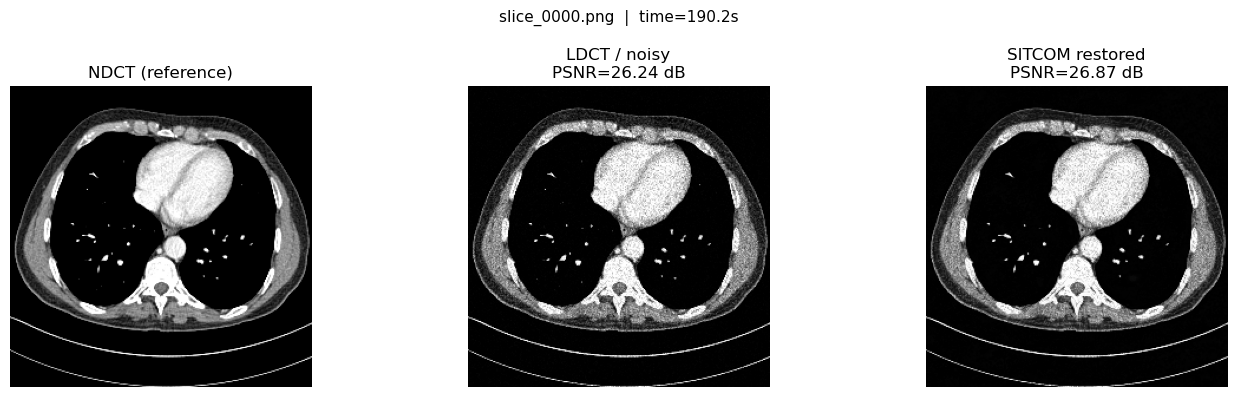

[2/4] Processing slice_0001.png ...


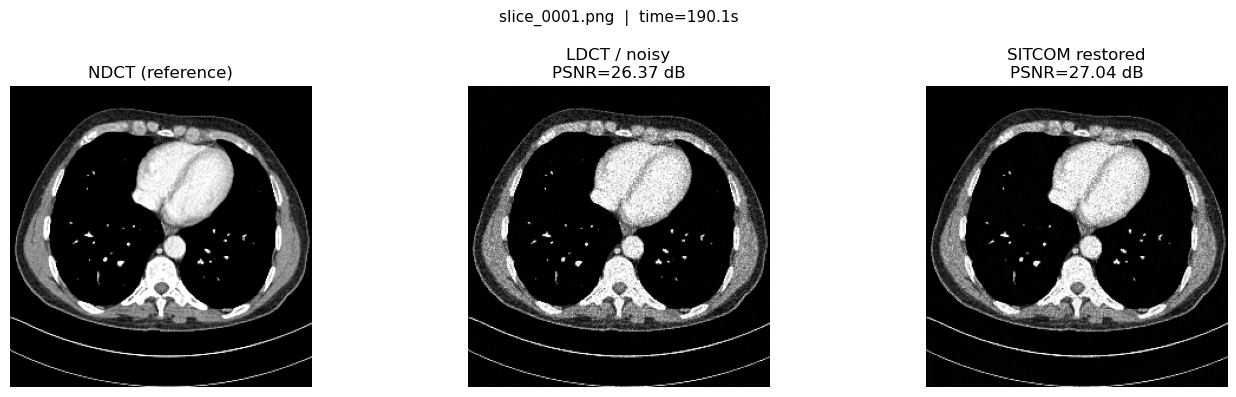

[3/4] Processing slice_0002.png ...


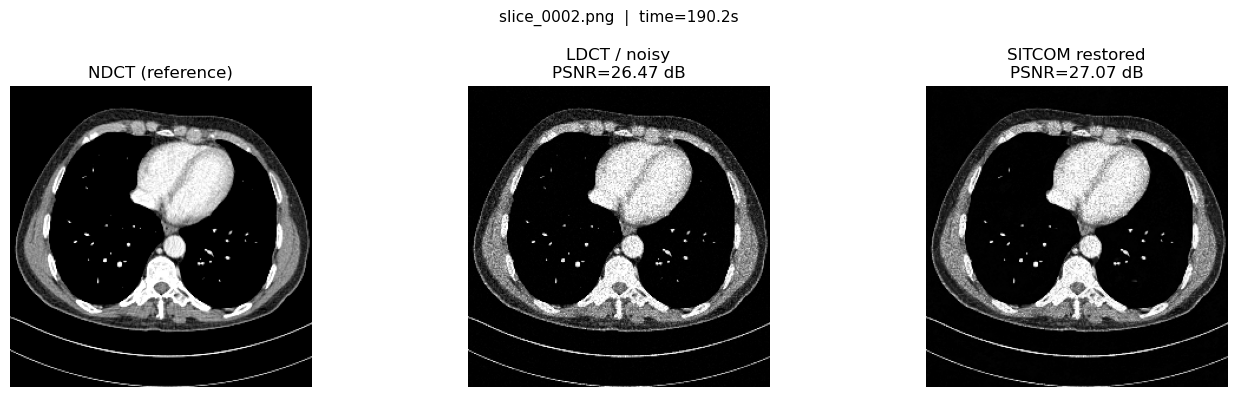

[4/4] Processing slice_0003.png ...


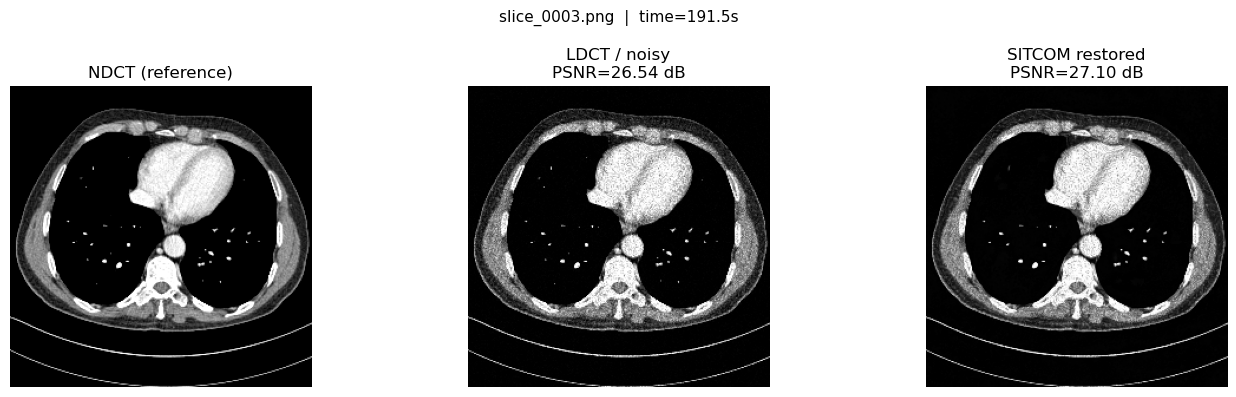


SITCOM LDCT Demo — Results Summary
slice_0000.png:  PSNR 26.24 → 26.87 dB  time=190.2s
slice_0001.png:  PSNR 26.37 → 27.04 dB  time=190.1s
slice_0002.png:  PSNR 26.47 → 27.07 dB  time=190.2s
slice_0003.png:  PSNR 26.54 → 27.10 dB  time=191.5s

Average PSNR gain : +0.615 dB


In [31]:
records = []

for idx, ndct_path in enumerate(ndct_files[:MAX_IMAGES]):
    ndct_01 = load_gray_png(ndct_path, IMAGE_SIZE)

    if USE_EXISTING_LDCT:
        ldct_path = LDCT_DIR / ndct_path.name
        if not ldct_path.exists():
            print(f"Skip {ndct_path.name}: missing paired LDCT file")
            continue
        ldct_01 = load_gray_png(ldct_path, IMAGE_SIZE)
    else:
        ldct_path = None
        ldct_01 = simulate_ldct_from_ndct(ndct_01)

    ndct_t = to_tensor_3ch(ndct_01).to(DEVICE)
    ldct_t = to_tensor_3ch(ldct_01).to(DEVICE)

    print(f"[{idx+1}/{min(MAX_IMAGES, len(ndct_files))}] Processing {ndct_path.name} ...")
    start = time.time()

    den_t = sitcom_ldct_denoise(
        model=model,
        scheduler=scheduler,
        y_obs_m11=ldct_t,
        k_inner=K_INNER,
        learning_rate=LEARNING_RATE,
        lam=LAMBDA,
        delta=DELTA,
    )
    elapsed = time.time() - start

    den_01 = to_01(den_t).cpu().numpy()[0, 0]

    psnr_noisy = peak_signal_noise_ratio(ndct_01, ldct_01, data_range=1.0)
    psnr_den   = peak_signal_noise_ratio(ndct_01, den_01, data_range=1.0)

    out_path = OUTPUT_DIR / (ndct_path.stem + "_sitcom_ldct.png")
    save_gray_png(den_01, out_path)

    records.append({
        "name": ndct_path.name,
        "psnr_noisy": psnr_noisy,
        "psnr_denoised": psnr_den,
        "time_sec": elapsed,
        "output": str(out_path),
    })

    # Visualisation
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    axes[0].imshow(ndct_01, cmap="gray", vmin=0, vmax=1)
    axes[0].set_title("NDCT (reference)")
    axes[0].axis("off")

    axes[1].imshow(ldct_01, cmap="gray", vmin=0, vmax=1)
    axes[1].set_title(f"LDCT / noisy\nPSNR={psnr_noisy:.2f} dB")
    axes[1].axis("off")

    axes[2].imshow(den_01, cmap="gray", vmin=0, vmax=1)
    axes[2].set_title(f"SITCOM restored\nPSNR={psnr_den:.2f} dB")
    axes[2].axis("off")

    fig.suptitle(f"{ndct_path.name}  |  time={elapsed:.1f}s", fontsize=11)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / (ndct_path.stem + "_comparison.png"), dpi=150, bbox_inches="tight")
    plt.show()


if len(records) == 0:
    print("No samples were processed. Check data paths and paired file names.")
else:
    avg_psnr_gain = np.mean([r["psnr_denoised"] - r["psnr_noisy"] for r in records])

    print("\n" + "="*50)
    print("SITCOM LDCT Demo — Results Summary")
    print("="*50)
    for r in records:
        print(
            f"{r['name']}:  "
            f"PSNR {r['psnr_noisy']:.2f} → {r['psnr_denoised']:.2f} dB  "
            f"time={r['time_sec']:.1f}s"
        )
    print(f"\nAverage PSNR gain : {avg_psnr_gain:+.3f} dB")
    #--------------------------------show info, you can uncomment it if you want to see the output folder info--------------------------------
    # print(f"Outputs saved to  : {OUTPUT_DIR}")


## Notes for Stronger LDCT Performance

- **CT-domain checkpoint**: The FFHQ checkpoint is for testing only. Retrain or fine-tune on CT data (e.g., AAPM 2016 dataset) for clinical-quality results.
- **Physics-faithful forward model**: Replace the identity operator `A = I` with a differentiable CT projection (Radon transform + Poisson noise) for sinogram-domain reconstruction.
- **Hyperparameter tuning**: `λ` (regularization) and `δ` (stopping threshold) are sensitive — start with `λ ∈ [0.05, 0.5]` and `δ ≈ noise_std`.
- **Increase K for quality**: Larger `K_INNER` (e.g., 100-200, in the notebook we use 200) generally improves results at the cost of runtime.